<a href="https://colab.research.google.com/github/vsaludesm/Visualizacion_USAL/blob/main/An%C3%A1lisis_Exploratorio_Datos_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
# Importación de Pandas
import pandas as pd

In [37]:
# Carga del Conjunto de Datos
df = pd.read_csv ('https://raw.githubusercontent.com/vsaludesm/Visualizacion_USAL/main/Datos_Visualizacion_2022-2025.csv', delimiter=';')

In [38]:
# Crear un mapeo de colores consistente para todos los sublinajes adaptado a problemas de visión
unique_sublinajes = sorted(df['Sublinaje_MTBC_Vis'].dropna().unique().tolist())
color_palette_consistent = sns.color_palette('colorblind', n_colors=len(unique_sublinajes))
sublinaje_color_map = dict(zip(unique_sublinajes, color_palette_consistent))

print("Mapeo de colores consistente creado:")
for sublinaje, color in sublinaje_color_map.items():
    print(f"{sublinaje}: {color}")

Mapeo de colores consistente creado:
L1: (0.00392156862745098, 0.45098039215686275, 0.6980392156862745)
L2: (0.8705882352941177, 0.5607843137254902, 0.0196078431372549)
L3: (0.00784313725490196, 0.6196078431372549, 0.45098039215686275)
L4.1.2.1: (0.8352941176470589, 0.3686274509803922, 0.0)
L4.3.2: (0.8, 0.47058823529411764, 0.7372549019607844)
L4.3.3: (0.792156862745098, 0.5686274509803921, 0.3803921568627451)
L4.3.4.2: (0.984313725490196, 0.6862745098039216, 0.8941176470588236)
L4.8: (0.5803921568627451, 0.5803921568627451, 0.5803921568627451)
L4_minor: (0.9254901960784314, 0.8823529411764706, 0.2)
L5_6: (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)
La: (0.00392156862745098, 0.45098039215686275, 0.6980392156862745)
La1.BCG: (0.8705882352941177, 0.5607843137254902, 0.0196078431372549)


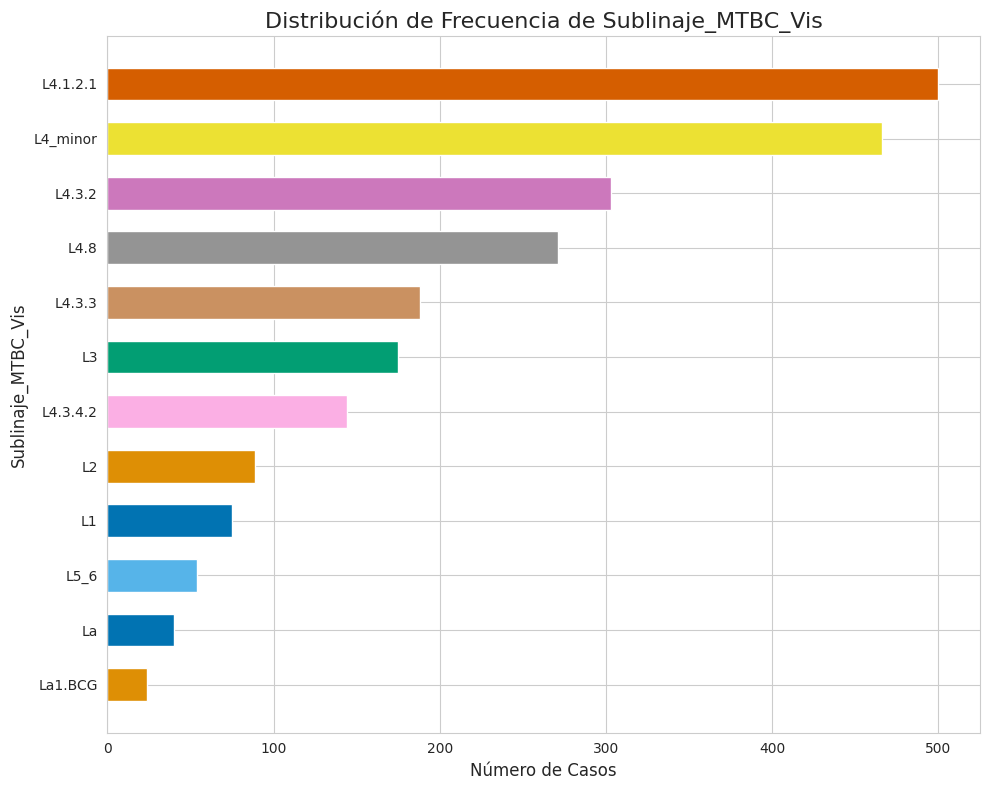

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Calcular la frecuencia total de cada Sublinaje_MTBC_Vis y ordenar de forma descendente
sublinaje_counts = frecuencias_df.sum().sort_values(ascending=False)

# Crear el gráfico de barras horizontal
fig, ax = plt.subplots(figsize=(10, 8))

# Obtener los colores correspondientes del mapeo consistente
# Asegurar que el orden de los colores coincide con el orden de sublinaje_counts
colors_for_bars = [sublinaje_color_map[sub] for sub in sublinaje_counts.index]

# Usar ax.barh para tener control directo sobre el ancho de las barras (altura para barras horizontales)
ax.barh(y=sublinaje_counts.index, width=sublinaje_counts.values, height=0.6, color=colors_for_bars) # 'height' controla el ancho de las barras horizontales

# Invertir el eje Y para que la sublínea más frecuente esté en la parte superior
ax.invert_yaxis()

# Añadir título y etiquetas
ax.set_title('Distribución de Frecuencia de Sublinaje_MTBC_Vis', fontsize=16)
ax.set_xlabel('Número de Casos', fontsize=12)
ax.set_ylabel('Sublinaje_MTBC_Vis', fontsize=12)

plt.tight_layout() # Ajustar el diseño
plt.show()

# Guardar el gráfico como imagen
fig.savefig('distribucion_sublinaje_horizontal_bar_chart.png', bbox_inches='tight')

In [40]:
# Generar un DataFrame con las frecuencias de 'Sublinaje_MTBC_Vis' por 'Fecha_toma_muestra_Vis'

# Definir una función para extraer año y trimestre para ordenar
def sort_quarters(quarter_str):
    if pd.isna(quarter_str): # Handle potential NaN values if any
        return (0, 0) # Place NaN at the beginning
    parts = quarter_str.split('_')
    q_num = int(parts[0][0])
    year = int(parts[1])
    return (year, q_num)

# Obtener el orden deseado de los trimestres
# Usar el índice de frecuencias_df directamente para asegurar que solo se usan los trimestres presentes
all_quarters = sorted(df['Fecha_toma_muestra_Vis'].dropna().unique().tolist(), key=sort_quarters)

# Convertir la columna 'Fecha_toma_muestra_Vis' a tipo categórico con el orden deseado
df['Fecha_toma_muestra_Vis'] = pd.Categorical(df['Fecha_toma_muestra_Vis'], categories=all_quarters, ordered=True)

frecuencias_df = pd.crosstab(df['Fecha_toma_muestra_Vis'], df['Sublinaje_MTBC_Vis'])

# Mostrar las primeras filas del nuevo DataFrame de frecuencias
display(frecuencias_df.head())

Sublinaje_MTBC_Vis,L1,L2,L3,L4.1.2.1,L4.3.2,L4.3.3,L4.3.4.2,L4.8,L4_minor,L5_6,La,La1.BCG
Fecha_toma_muestra_Vis,,,,,,,,,,,,
1T_2022,4,4,5,34,16,13,18,21,35,5,1,2
2T_2022,8,5,9,29,29,8,8,22,32,2,0,3
3T_2022,1,5,8,40,12,12,4,15,28,1,2,0
4T_2022,2,7,11,23,17,10,5,23,29,4,0,0
1T_2023,2,3,14,30,26,15,8,21,38,3,4,1


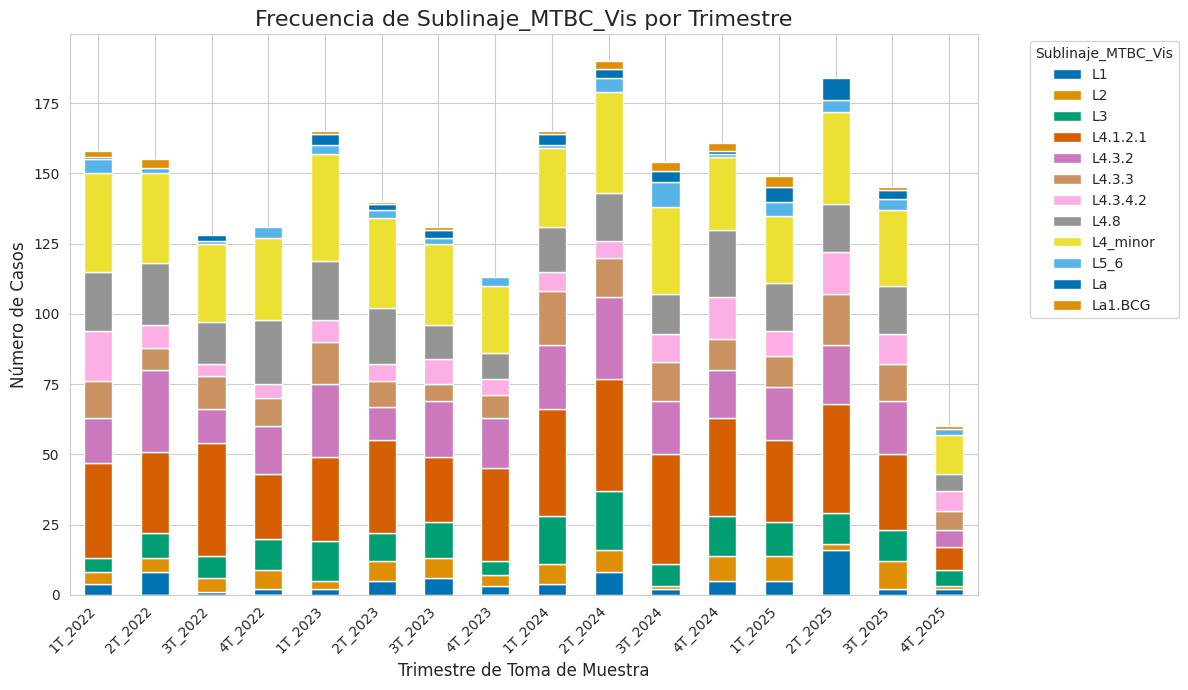

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Crear un gráfico de barras apiladas
fig, ax = plt.subplots(figsize=(12, 7)) # Ajustar el tamaño de la figura para mejor visibilidad

# Reordenar las columnas de frecuencias_df para que coincidan con unique_sublinajes para una asignación de color consistente
# Asegurar que todas las columnas de frecuencias_df están en sublinaje_color_map
columns_to_plot = [col for col in unique_sublinajes if col in frecuencias_df.columns]
frecuencias_df[columns_to_plot].plot(kind='bar', stacked=True, ax=ax, color=[sublinaje_color_map[col] for col in columns_to_plot])

# Añadir título y etiquetas
ax.set_title('Frecuencia de Sublinaje_MTBC_Vis por Trimestre', fontsize=16)
ax.set_xlabel('Trimestre de Toma de Muestra', fontsize=12)
ax.set_ylabel('Número de Casos', fontsize=12)

# Establecer explícitamente los ticks del eje X para mostrar todos los trimestres
ax.set_xticks(range(len(frecuencias_df.index)))
ax.set_xticklabels(frecuencias_df.index, rotation=45, ha='right')

# Mover la leyenda fuera del gráfico para que no lo tape
ax.legend(title='Sublinaje_MTBC_Vis', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout() # Ajustar el diseño para evitar que las etiquetas se corten
plt.show()

# Guardar el gráfico como imagen
fig.savefig('frecuencia_sublinaje_trimestre_bar_chart.png', bbox_inches='tight')

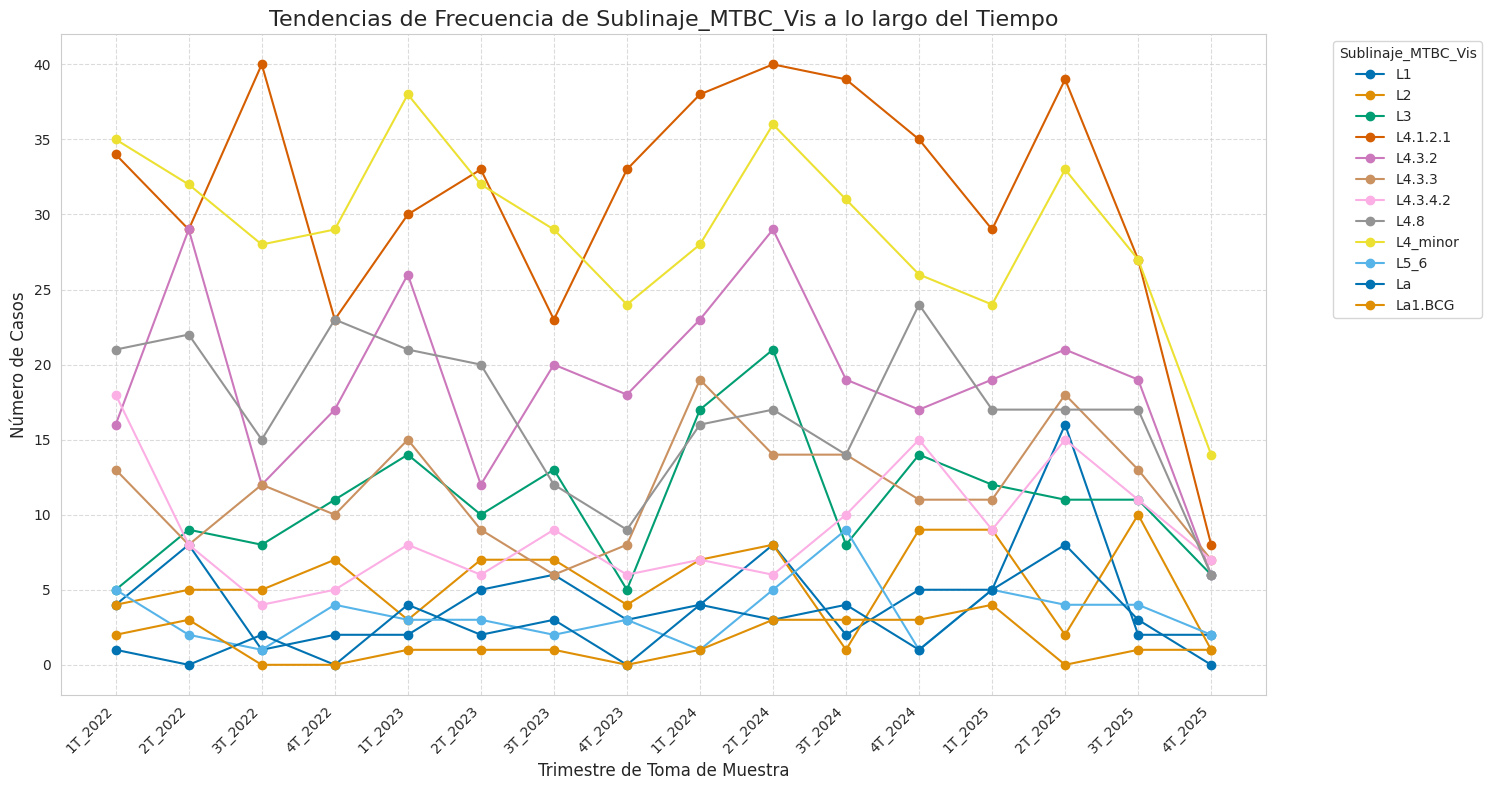

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Crear un gráfico de líneas para observar tendencias temporales
fig, ax = plt.subplots(figsize=(15, 8)) # Ajustar el tamaño de la figura

# Reordenar las columnas de frecuencias_df para que coincidan con unique_sublinajes para una asignación de color consistente
# Asegurar que todas las columnas de frecuencias_df están en sublinaje_color_map
columns_to_plot = [col for col in unique_sublinajes if col in frecuencias_df.columns]
frecuencias_df[columns_to_plot].plot(kind='line', ax=ax, marker='o', color=[sublinaje_color_map[col] for col in columns_to_plot])

# Añadir título y etiquetas
ax.set_title('Tendencias de Frecuencia de Sublinaje_MTBC_Vis a lo largo del Tiempo', fontsize=16)
ax.set_xlabel('Trimestre de Toma de Muestra', fontsize=12)
ax.set_ylabel('Número de Casos', fontsize=12)

# Establecer explícitamente los ticks del eje X para mostrar todos los trimestres
ax.set_xticks(range(len(frecuencias_df.index)))
ax.set_xticklabels(frecuencias_df.index, rotation=45, ha='right')

# Mover la leyenda fuera del gráfico para que no lo tape
ax.legend(title='Sublinaje_MTBC_Vis', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.7) # Añadir una cuadrícula para mejor lectura
plt.tight_layout() # Ajustar el diseño
plt.show()

# Guardar el gráfico como imagen
fig.savefig('tendencias_frecuencia_sublinaje_line_chart.png', bbox_inches='tight')